In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime as DT
from datetime import timedelta
import calendar
import seaborn as sns
from scipy.optimize import curve_fit as cf

import pmdarima as pmd

In [2]:
def X_date_format(fig,ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # Ticks every 6 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator()) # Minor ticks every month
    fig.autofmt_xdate()

# Openning Data

In [3]:
data = pd.read_csv('Nat_Gas.csv')
data['Dates'] = pd.to_datetime(data['Dates'], format="%m/%d/%y")
OG_data = data.copy()
data.set_index("Dates",inplace=True)

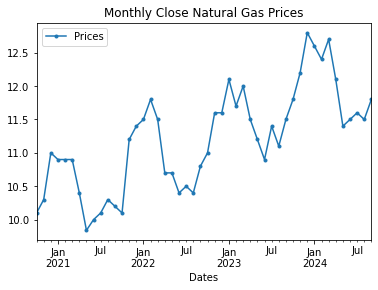

In [4]:
data.plot(style='.-',title="Monthly Close Natural Gas Prices");

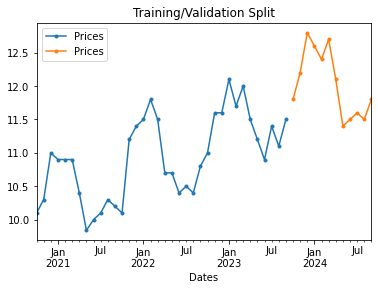

In [5]:
valid_start = -12

train = data.iloc[0:valid_start]
valid = data.iloc[valid_start:]

fig,ax = plt.subplots()
train.plot(ax=ax,style='.-')
valid.plot(ax=ax,style='.-')
ax.set_title("Training/Validation Split");

# Creating the Models

## SARIMA model

In [6]:
x_train = train.index
x_valid = valid.index

y_train = train["Prices"]
y_valid = valid["Prices"]

In [7]:
model_sarima = pmd.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    m=12,
    seasonal=True,
    trend='t',
    test='adf',
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True
)

print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 -15.101
Date:                            Sat, 16 Aug 2025   AIC                             42.202
Time:                                    22:10:39   BIC                             51.703
Sample:                                10-31-2020   HQIC                            45.518
                                     - 09-30-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift          0.0010      0.001      0.932      0.352      -0.001       0.003
ar.L1          0.9948      0.008   

## Model Check

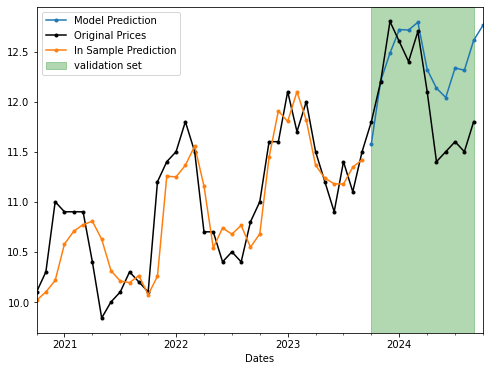

In [8]:
new_data_1 = pd.DataFrame(model_sarima.predict(n_periods=13))
in_sample = pd.DataFrame(model_sarima.predict_in_sample())

fig, ax = plt.subplots(figsize=(8,6))

lines1 = new_data_1.plot(ax=ax, style='.-').get_lines()
lines1 = ax.get_lines()[-len(new_data_1.columns):] 
lines1[0].set_label("Model Prediction")

lines2 = data.plot(ax=ax, style='.-',color='k').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")

lines3 = in_sample.plot(ax=ax, style='.-').get_lines()
lines3 = ax.get_lines()[-len(in_sample.columns):] 
lines3[0].set_label("In Sample Prediction")

ax.axvspan(data.index[valid_start],data.index[-1], alpha=0.3, color='green',label='validation set')
ax.legend()
plt.show()

## Brownian motion around time dependent mean

Sometimes, the simplest of models are better if we don't have a lot of data

In [11]:
# First we need to find a function for the mean
# It should oscillate and grown linearly in time

def Mean(t,A,B,C,D,E):
    return A*t + B*np.sin(C*t + D) + E

# let the time data have an arbitrary scale
X = np.arange(data["Prices"].size)

# Now fit the data, using all of it
MofT_FIT = cf(Mean,X,data["Prices"].values, p0=[0.5,3,0.5,0,10])
MofT_params = MofT_FIT[0]

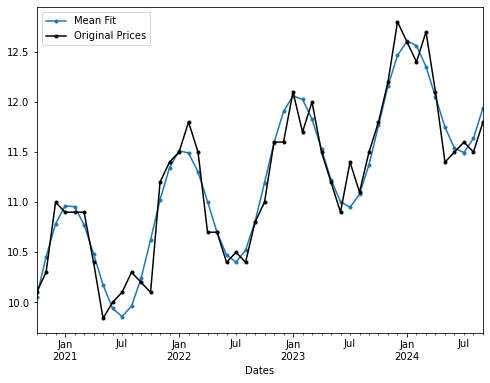

In [12]:
MofT = Mean(X,*MofT_params)
MofT = pd.DataFrame(MofT,columns=['Prices'])
MofT.index = data.index

fig,ax = plt.subplots(figsize=(8,6))

lines1 = MofT.plot(ax=ax,style='.-').get_lines()
lines1 = ax.get_lines()
lines1[0].set_label("Mean Fit")

lines2 = data.plot(ax=ax,style='.-',color='k').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")

ax.legend();
plt.show();

Maximum Likelihood Estimation for variance: 0.039. Computing sample path..


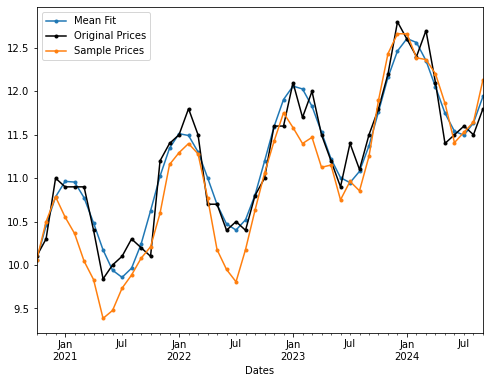

In [15]:
# Now, we know that the best estimate for the variance, is just the error in the fit!
var = (1/data['Prices'].size) * np.sum( ( data['Prices'] - MofT['Prices'] )**2 )
print("Maximum Likelihood Estimation for variance: {:.3f}. Computing sample path..".format(var))

# calculate path with random noise
n_steps = data['Prices'].size
noise = np.random.normal(0,1,size = n_steps-1)
dt = 1
dM = np.diff(MofT['Prices'].values)
sigma = np.sqrt(var)

# calculate steps with mean fit and most likely variance
increments = dM + sigma*np.sqrt(dt)*noise
path = np.zeros(n_steps)
path[0] = MofT['Prices'].values[0]

#calculate path is cumulative sum of increments and initial condition
path[1:] = np.cumsum(increments) + path[0]


fig,ax = plt.subplots(figsize=(8,6))

lines1 = MofT.plot(ax=ax,style='.-').get_lines()
lines1 = ax.get_lines()
lines1[0].set_label("Mean Fit")

lines2 = data.plot(ax=ax,style='.-',color='k').get_lines()
lines2 = ax.get_lines()[-len(data.columns):]
lines2[0].set_label("Original Prices")


path = pd.DataFrame(path,index=data.index,columns=['Sample Prices'])
path.plot(ax=ax,style='.-')

ax.legend();
plt.show();

# Computing list of dates

We will need this for testing our functions

In [16]:
def date_list(start_date_str, end_date_str,last_day_of_month=False):
    """ Input a start and end date and output all dates in between, inclusive. Date string must be of the form:

        MM/DD/YY
        
        If last_day_of_month is true, it will only return the last day of the month beteen the the dates.
    """
    # Example input:
    # start_date_str = "8/31/24"
    # end_date_str = "12/7/26"
    start_date_in = DT.strptime(start_date_str, "%m/%d/%y")
    end_date_in = DT.strptime(end_date_str, "%m/%d/%y")
    start_date = min(start_date_in, end_date_in)
    end_date = max(start_date_in, end_date_in)
    
    days_delta = 1
    if last_day_of_month:
        last_day = calendar.monthrange(start_date.year, start_date.month)[1]
        start_date = start_date.replace(day=last_day)
        last_day = calendar.monthrange(end_date.year, end_date.month)[1]
        end_date = end_date.replace(day=last_day)
        days_delta = 7

    dates_list = []
    current_date = start_date
    while current_date <= end_date:
        dates_list.append(current_date)
        current_date += timedelta(days=days_delta)
        if last_day_of_month:
            last_day = calendar.monthrange(current_date.year, current_date.month)[1]
            current_date = current_date.replace(day=last_day)
    
    return pd.Series(pd.to_datetime(dates_list))

### Function for displaying statistics of mean + noise model

In [17]:
def Display_Statistics(paths, new_MofT, dates, CI=0.5, print_all_values=False):
    """
    Function which takes in a pandas DataFrame of simulated paths and produces statistics and plots
    relevant for estimations (future or past).
    Should also input the past extrpolated time dependent mean.
    The dates of the original query. Should be of the format:
        dates[0] = most recent with respect to data, dates[1] = further
    CI is coonfidence interval of reported statistics, between 0 and 1.
    print_all_values prints the median value of all dates originally queried in the date list.
    """
    qL = CI - CI/2
    qH = CI + CI/2 
    QL = paths.quantile(q=qL,axis=1)
    QH = paths.quantile(q=qH,axis=1)
    median = paths.quantile(q=0.5,axis=1)
    recent = median.index==dates[0]
    further = median.index==dates[1]
    median.rename("Median Price Path",inplace=True)
    
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(data.index,data['Prices'],linestyle='-',marker='o',color='k',label='Original Price Data')
    ax.plot(data.index,MofT,color='c',label="Data Average Price")
    ax.plot(paths.index,median,color='green',label='Median Simuated Path')
    ax.plot(paths.index,new_MofT,color='blue',label="Extrapolated Mean")
    ax.fill_between(paths.index,QL,QH,color='red',alpha=0.4,label='{:.1f}% - {:.1f}%'.format(qL*100,qH*100));
    ax.axvspan(median.index[further][0],median.index[recent][0], alpha=0.15, color='green',label='Queried Dates')
    
    X_date_format(fig,ax)
    ax.set_ylabel('Prices',size=12)
    ax.legend()
    plt.show()
    
    print("Final predicted value on {} given by simulation median: {:.3f}\n".format(paths.index[-1].strftime('%m/%d/%y'),median.iat[-1]))
    print("We expect the value to lie between {:.3f} and {:.3f} with {:.1f}% confidence.\n".format(QL.iat[-1],QH.iat[-1],CI*100))
    if print_all_values:
        print("Predicted values of queried dates given by simulations median:")
        mask = (median.index >= min(dates[0],dates[1])) & (median.index <= max(dates[0],dates[1]))
        print(median[mask])
    return median

# Past Estimations

We cannot use the SARIMA time series to make estimations of the past, so we only use our fitted model + noise for this.

In [18]:
def Simulate_Past(dates_list, n_paths=100,DOWNTUNE_SLOPE=1.0):
    """ 
    Function that takes in a list of dates in the past (relative to the original data) and
    returns n_paths simulations which can be used to estimate statistics.
    dates_list should be a pandas Series.
    DOWNTUNE_SLOPE must be > 0 and <= 1
    """
    if DOWNTUNE_SLOPE > 1 or DOWNTUNE_SLOPE < 0:
        print("DOWNTUNE_SLOPE must be between 0 and 1.")
        return
    delta_days = (dates_list.sort_values(ascending=False) - data.index[0]).dt.days
    
    Last_Day = delta_days.iat[-1]
    if Last_Day > 0:
        print("Only past dates allowed.")
        return
#     n_paths = 100
    n_steps = abs(Last_Day)
    
    # Since we will now simulate DAILY values, we need to transfrom our rates (parameters)
    # Before we had delta_t ~ 1 month, so now we need to scale from months to days
    # Let's assume there are 365/12 = 30.4 days in a month and convert to the proper date afterwards
    dt = 1/30.4
    X = np.arange(0,Last_Day-1,-1,dtype=float)
    a,b,c,d,e = MofT_params
    # rescaling paramteres, only a and c need to be rescaled
    a *= dt
    c *= dt
    
    MofT = Mean(X,a*DOWNTUNE_SLOPE,b,c,d,e)
    noise = np.random.normal(0,1,size = (n_paths,n_steps))
    dM = np.diff(MofT)
    sigma = np.sqrt(var)

    # calculate steps with scaled mean fit and variance
    increments = dM + sigma*np.sqrt(dt)*noise
    paths = np.zeros((n_paths,n_steps+1))
    paths[:,0] = data['Prices'][0]
    
    #calculate path is cumulative sum of increments and initial condition
    paths[:,1:] = np.cumsum(increments, axis=1) + data['Prices'][0]
    
    X = pd.Series(X)
    new_date_index = data.index[0] + pd.to_timedelta(X, unit='D')
    paths = pd.DataFrame(paths.transpose(), index=new_date_index)
    
    return paths,MofT

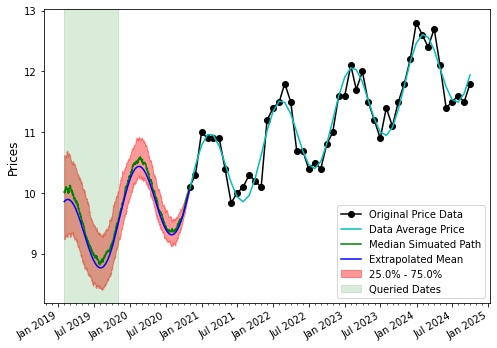

Final predicted value on 01/31/19 given by simulation median: 10.018

We expect the value to lie between 9.245 and 10.590 with 50.0% confidence.

Predicted values of queried dates given by simulations median:
2019-10-30     9.500301
2019-10-29     9.510055
2019-10-28     9.500626
2019-10-27     9.502891
2019-10-26     9.475701
                ...    
2019-02-04    10.024147
2019-02-03    10.019117
2019-02-02    10.002103
2019-02-01    10.029718
2019-01-31    10.018357
Name: Median Price Path, Length: 273, dtype: float64


In [19]:
date1 = "10/30/19"
date2 = "1/31/19"
test_past = date_list(date1,date2)

paths, past_MofT = Simulate_Past(test_past)
Display_Statistics(paths, past_MofT, (test_past.iat[-1],test_past.iat[0]), print_all_values=True);

One might expect that the data is given during a particuarly inflationary time (COVID-19, war in Ukraine, etc). So, we also include a DOWNTUNE paramter to downsize the slope from the original fit. 

### Downtuned slope

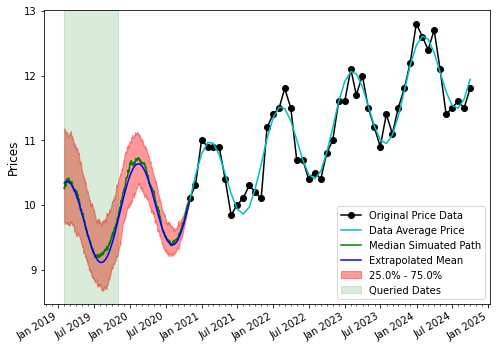

Final predicted value on 01/31/19 given by simulation median: 10.258

We expect the value to lie between 9.741 and 11.183 with 50.0% confidence.

Predicted values of queried dates given by simulations median:
2019-10-30     9.806577
2019-10-29     9.785384
2019-10-28     9.786446
2019-10-27     9.732060
2019-10-26     9.738181
                ...    
2019-02-04    10.303200
2019-02-03    10.280779
2019-02-02    10.299279
2019-02-01    10.248177
2019-01-31    10.258412
Name: Median Price Path, Length: 273, dtype: float64


In [20]:
paths, past_MofT = Simulate_Past(test_past,DOWNTUNE_SLOPE=0.5)
Display_Statistics(paths, past_MofT, (test_past.iat[-1],test_past.iat[0]), print_all_values=True);

# Future Extrapolation

## SARIMA MODEL (simple execution, complicated under the hood)

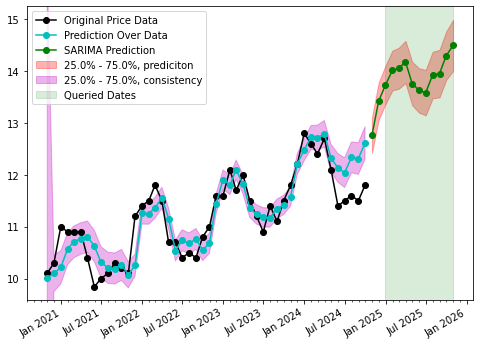

Final predicted value on 10/31/25 given by simulation median: 14.493

We expect the value to lie between 13.999 and 14.988 with 50.0% confidence.

Predicted values of queried dates given by SARIMA model:
2024-12-31    13.734528
2025-01-31    14.010466
2025-02-28    14.051119
2025-03-31    14.174597
2025-04-30    13.759398
2025-05-31    13.625038
2025-06-30    13.582953
2025-07-31    13.922219
2025-08-31    13.950300
2025-09-30    14.294516
2025-10-31    14.493325
Freq: M, dtype: float64


In [21]:
def SARIMA_future(dates_list, CI=0.5, display=True, print_all_values=False):
    """
        Function that takes in list of dates in the future and outputs the model prediction along with
        confidence intervals of prediction.
        dates_list should be a pandas Series.
    """
    early_date = min(dates_list)
    if (early_date - data.index[-1]).days < 0:
        print("Earliest date must be after original data.")
        return None
    
    end_of_months = date_list(DT.strftime(data.index[-1],format='%m/%d/%y'),
                              DT.strftime(dates_list.iat[-1],format='%m/%d/%y'),
                              True)    
    shift = abs(valid_start)
    delta = end_of_months.size + shift - 1
    prediction_whole, conf_int_whole = model_sarima.predict(delta, return_conf_int=True, alpha=CI)
    prediction = prediction_whole[shift:]
    conf_int = conf_int_whole[shift:]
    
    if display:
        in_sample,CI_sample = model_sarima.predict_in_sample(return_conf_int=True,alpha=CI)

        fig, ax = plt.subplots(figsize=(8,6))

        ax.plot(data.index,data['Prices'],linestyle='-',marker='o',color='k',label='Original Price Data')
        ax.plot(in_sample.index,in_sample,linestyle='-',marker='o',color='c',label='Prediction Over Data')    
        ax.plot(prediction_whole.index[:shift],prediction_whole[:shift],linestyle='-',marker='o',color='c')
        ax.plot(prediction.index,prediction,color='g',linestyle='-',marker='o',label='SARIMA Prediction')
        qL, qH = CI - CI/2, CI + CI/2
        ax.fill_between(prediction.index[:], conf_int[:,0],
                        conf_int[:,1],color='r',alpha=0.3,
                        label='{:.1f}% - {:.1f}%, prediciton'.format(qL*100,qH*100))

        main_xlim = ax.get_xlim()
        main_ylim = ax.get_ylim()    

        in_sample_CI = np.concatenate((CI_sample, conf_int_whole[:shift]),axis=0)
        ax.fill_between(data.index, in_sample_CI[:,0],
                        in_sample_CI[:,1],color='m',alpha=0.3,
                        label='{:.1f}% - {:.1f}%, consistency'.format(qL*100,qH*100), zorder=-1)
        ax.axvspan(min(dates_list),max(dates_list), alpha=0.15, color='green',label='Queried Dates')

        ax.set_xlim(main_xlim)
        ax.set_ylim(main_ylim)
        X_date_format(fig,ax)
        ax.legend()
        plt.show()
        print("Final predicted value on {} given by simulation median: {:.3f}\n".format(
                                            prediction.index[-1].strftime('%m/%d/%y'),prediction.iat[-1]))
        print("We expect the value to lie between {:.3f} and {:.3f} with {:.1f}% confidence.\n".format(
                                            conf_int[-1,0],conf_int[-1,1],CI*100))
        
    if print_all_values:
        print("Predicted values of queried dates given by SARIMA model:")
        mask = ((prediction.index >= min(dates_list)) & (prediction.index <= max(dates_list)))
        print(prediction[mask])
    prediction.rename("Predicted Price Path",inplace=True)
    return prediction, conf_int
        
    
date1 = "12/31/24"
date2 = "10/31/25"
test = date_list(date1,date2)
SARIMA_future(test,print_all_values=True);

## Mean + noise model (more complex execution, simpler "under the hood")

In [22]:
def Simulate_Future(dates_list, n_paths=100,DOWNTUNE_SLOPE=1.0):
    """ 
    Function that takes in a list of dates in the future (relative to the original data) and
    returns n_paths simulations which can be used to estimate statistics.
    dates_list should be a pandas Series.
    DOWNTUNE_SLOPE must be > 0 and <= 1
    """
    if DOWNTUNE_SLOPE > 1 or DOWNTUNE_SLOPE < 0:
        print("DOWNTUNE_SLOPE must be between 0 and 1.")
        return
    delta_days = (dates_list.sort_values() - data.index[-1]).dt.days
    
    First_Day = delta_days.iat[0]
    if First_Day < 0:
        print("Only future dates allowed.")
        return
#     n_paths = 100

    DAY_SHIFT = (data.index[-1] - data.index[0]).days
    Last_Day = delta_days.iat[-1]
    n_steps = Last_Day
    
    # Since we will now simulate DAILY values, we need to transfrom our rates (parameters)
    # Before we had delta_t ~ 1 month, so now we need to scale from months to days
    # Let's assume there are 365/12 = 30.4 days in a month and convert to the proper date afterwards
    dt = 1/30.4
    X = np.arange(DAY_SHIFT,Last_Day+1+DAY_SHIFT,1,dtype=float)
    a,b,c,d,e = MofT_params
    # rescaling paramteres, only a and c need to be rescaled
    a *= dt
    c *= dt
    
    MofT = Mean(X,a*DOWNTUNE_SLOPE,b,c,d,e)
    noise = np.random.normal(0,1,size = (n_paths,n_steps))
    dM = np.diff(MofT)
    sigma = np.sqrt(var)

    # calculate steps with scaled mean fit and variance
    increments = dM + sigma*np.sqrt(dt)*noise
    paths = np.zeros((n_paths,n_steps+1))
    paths[:,0] = data['Prices'][-1]
    
    #calculate path is cumulative sum of increments and initial condition
    paths[:,1:] = np.cumsum(increments, axis=1) + data['Prices'][-1]
    
    X = pd.Series(X)
    new_date_index = data.index[0] + pd.to_timedelta(X, unit='D')
    paths = pd.DataFrame(paths.transpose(), index=new_date_index)
    
    return paths,MofT

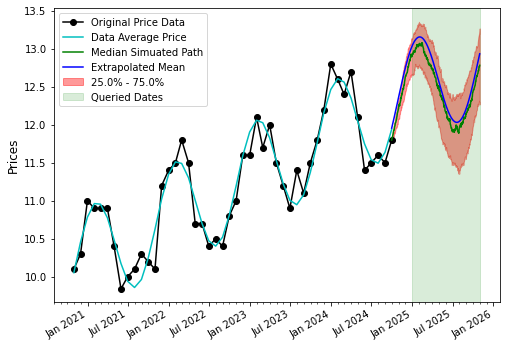

Final predicted value on 10/31/25 given by simulation median: 12.783

We expect the value to lie between 12.268 and 13.270 with 50.0% confidence.

Predicted values of queried dates given by simulations median:
2024-12-31    12.905476
2025-01-01    12.920453
2025-01-02    12.937236
2025-01-03    12.928457
2025-01-04    12.932262
                ...    
2025-10-27    12.727455
2025-10-28    12.760592
2025-10-29    12.769092
2025-10-30    12.766978
2025-10-31    12.783135
Name: Median Price Path, Length: 305, dtype: float64


In [23]:
date1 = "12/31/24"
date2 = "10/31/25"
test = date_list(date1,date2)

paths_future, future_MofT = Simulate_Future(test)
Display_Statistics(paths_future, future_MofT, (test.iat[0],test.iat[-1]), print_all_values=True);

# Final Function: Put in list of dates, Output statistics

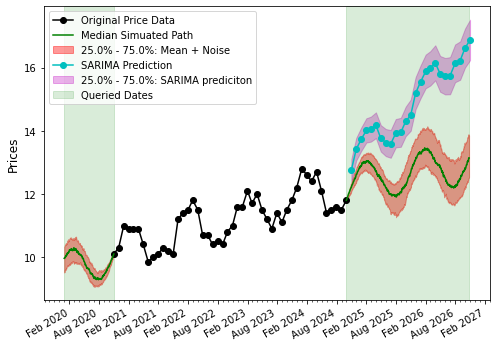

----------------------------------------------------------------------------------------------------
Final predicted PAST value given by MEAN + NOISE MODEL on 12/31/19,
    given by simulation median: 9.960

Expecting the value to lie between 9.511 and 10.327 with 50.0% confidence.

----------------------------------------------------------------------------------------------------
Final predicted FUTURE value given by MEAN + NOISE MODEL on 10/25/26,
    given by simulation median: 13.142

Expecting the value to lie between 12.539 and 13.855 with 50.0% confidence.

----------------------------------------------------------------------------------------------------
Interpolating final SARIMA VALUE (linear)...
Final predicted FUTURE value given by SARIMA MODEL on 10/25/26: 16.826

Expecting the value to lie between 16.189 and 17.463 with 50.0% confidence.



In [24]:
def Final_Output(dates_list, CI=0.5, n_paths=100, DOWNTUNE_SLOPE=1.0):
    past = dates_list[dates_list<min(data.index)]
    future = dates_list[dates_list>max(data.index)]
    within_data = dates_list[ (dates_list>=min(data.index))&(dates_list<=max(data.index)) ]   

    qL = CI - CI/2
    qH = CI + CI/2    
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(data.index,data['Prices'],linestyle='-',marker='o',color='k',label='Original Price Data')

    ### FIRST PAST ###
    if not past.empty:
        paths_past,past_MofT = Simulate_Past(past, n_paths=n_paths, DOWNTUNE_SLOPE=DOWNTUNE_SLOPE)
        dates_past = (past.iat[-1],past.iat[0])
        QL_past = paths_past.quantile(q=qL,axis=1)
        QH_past = paths_past.quantile(q=qH,axis=1)
        median_past = paths_past.quantile(q=0.5,axis=1)
        recent_past = median_past.index==dates_past[0]
        further_past = median_past.index==dates_past[1]
        median_past.rename("Median Price Path - Past",inplace=True)
        ax.plot(paths_past.index,median_past,color='green',label='Median Simuated Path')
        ax.fill_between(paths_past.index,QL_past,QH_past,color='red',alpha=0.4,
                        label='{:.1f}% - {:.1f}%: Mean + Noise'.format(qL*100,qH*100));
        ax.axvspan(median_past.index[further_past][0],median_past.index[recent_past][0],
                        alpha=0.15, color='green');
    
    ### FUTURE: MEAN + NOISE ###
    if not future.empty:
        paths_future,future_MofT = Simulate_Future(future, n_paths=n_paths, DOWNTUNE_SLOPE=DOWNTUNE_SLOPE)
        dates_future = (future.iat[0],future.iat[-1])
        QL_future = paths_future.quantile(q=qL,axis=1)
        QH_future = paths_future.quantile(q=qH,axis=1)
        median_future = paths_future.quantile(q=0.5,axis=1)
        recent_future = median_future.index==dates_future[0]
        further_future = median_future.index==dates_future[1]
        median_future.rename("Median Price Path - Future",inplace=True)
        ax.plot(paths_future.index,median_future,color='green')
        ax.fill_between(paths_future.index,QL_future,QH_future,color='red',alpha=0.4);

        
    ### FUTURE: SARIMA ###
        sarima_predict, conf_int = SARIMA_future(future, CI=CI, display=False, print_all_values=False)
        
        ax.plot(sarima_predict.index,sarima_predict,color='c',linestyle='-',marker='o',label='SARIMA Prediction')
        qL, qH = CI - CI/2, CI + CI/2
        ax.fill_between(sarima_predict.index[:], conf_int[:,0],
                        conf_int[:,1],color='m',alpha=0.3,
                        label='{:.1f}% - {:.1f}%: SARIMA prediciton'.format(qL*100,qH*100))
    ################################################
    # Queried dates of future, applies for SARIMA and mean + noise
        ax.axvspan(median_future.index[further_future][0],median_future.index[recent_future][0],
                    alpha=0.15, color='green',label='Queried Dates');
    

    
    X_date_format(fig,ax)
    ax.set_ylabel('Prices',size=12)
    ax.legend(loc='best')
    plt.show()

    print("-----"*20)
    
    print("""Final predicted PAST value given by MEAN + NOISE MODEL on {},
    given by simulation median: {:.3f}\n""".format(
                                        past.iat[0].strftime('%m/%d/%y'),median_past.iat[-1]))
    
    print("Expecting the value to lie between {:.3f} and {:.3f} with {:.1f}% confidence.\n".format(
                                                    QL_past.iat[-1],QH_past.iat[-1],CI*100))    
    
    
    print("-----"*20)
    
    print("""Final predicted FUTURE value given by MEAN + NOISE MODEL on {},
    given by simulation median: {:.3f}\n""".format(
                                        future.iat[-1].strftime('%m/%d/%y'),median_future.iat[-1]))
    
    print("Expecting the value to lie between {:.3f} and {:.3f} with {:.1f}% confidence.\n".format(
                                                    QL_future.iat[-1],QH_future.iat[-1],CI*100))
    
    print("-----"*20)
    
    # If the last day of the future queried dates is not at the end of the month, the SARIMA
    # model will go too far, so we should interpolate to get middle of the month results
    final_sarima_val = sarima_predict.iat[-1]
    lower_sarima_ci = conf_int[-1,0]
    higher_sarima_ci = conf_int[-1,1]
    last_predicted_day = future.iat[-1]
    last_day_month = last_predicted_day.month
    next_days_month = (last_predicted_day + timedelta(days=1)).month
    if last_day_month == next_days_month:
        print("Interpolating final SARIMA VALUE (linear)...")
        year = last_predicted_day.year
        weekday, num_days = calendar.monthrange(year, last_day_month)
        proportion = last_predicted_day.day/num_days
        final_sarima_val = sarima_predict.iat[-2] \
                                        + (sarima_predict.iat[-1] - sarima_predict.iat[-2])*proportion
        lower_sarima_ci = conf_int[-2,0] + (conf_int[-1,0] - conf_int[-2,0])*proportion
        higher_sarima_ci = conf_int[-2,1] + (conf_int[-1,1] - conf_int[-2,1])*proportion
    
    print("""Final predicted FUTURE value given by SARIMA MODEL on {}: {:.3f}\n""".format(
                                        future.iat[-1].strftime('%m/%d/%y'),final_sarima_val))
    
    print("Expecting the value to lie between {:.3f} and {:.3f} with {:.1f}% confidence.\n".format(
                                        lower_sarima_ci,higher_sarima_ci,CI*100))
    
    
date1 = "12/31/19"
date2 = "10/25/26"
combined_test = date_list(date1,date2)
Final_Output(combined_test)